# Annual airmass frequencies:

Notebook produces:

- Figure S22

We use the file:

``ZEP_class_seasector.dat``

In [47]:
import pandas as pd
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

loadpath_ZEP_class_seasector = r'C:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Analysis\back_trajectories_data\sectors'
filename = 'ZEP_class_seasector.dat'

In [48]:
def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [49]:
ZEP_class_resampled_merged = pd.read_csv(loadpath_ZEP_class_seasector+'\\'+filename,
                                         index_col=0, parse_dates=True)

In [50]:
ZEP_class_resampled_merged['month'] = ZEP_class_resampled_merged.index.month

regions = ZEP_class_resampled_merged['region_name'].unique()
print(regions)
regions = ['Arctic Ocean', 'Greenland Sea', 'Barents Sea', 'Norwegian Sea',
       'Kara Sea']

<ArrowStringArray>
['Arctic Ocean', 'Greenland Sea', 'Barents Sea', 'Norwegian Sea', 'Kara Sea']
Length: 5, dtype: str


In [51]:
ZEP_class_resampled_merged.head(2)

,Class Ia,Class Ib,Class II,Undefined,Non-event,too little data,event,total,mask_region,count,daily_count,fraction,region_name,month
2022-04-17,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31243,56905,0.549038,Arctic Ocean,4
2022-04-20,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,25301,46900,0.539467,Arctic Ocean,4


In [52]:
def plot_annual_regions(df_months_regions, nb_regions, dict_region_to_colors):
    df_months_regions['index'] = df_months_regions.index

    region_cols = df_months_regions.columns    
    region_cols = [x for x in region_cols if 'region' in x]
    print(region_cols)
    
    region_cols = [x.replace('_',' ')[:9] for x in region_cols]
    df_months_regions.columns = region_cols + ['month_sum', 'check_percentage_sum', 'index']
    
    colors=cm.rainbow(np.linspace(0,1,int(nb_regions)))   
    print(colors)
    #columns_and_colors = zip(region_cols, colors)
    colors = [*dict_region_to_colors.values()]
    ax = df_months_regions.plot(x='index', y=region_cols, kind='bar', stacked=True, figsize=(10,7), 
                                color=colors)
    
    ax.set_title("",color='black')
    ax.legend(['North Atlantic', 'Greenland', 'Arctic Ocean', 'Siberia', 'Eurasia'],
               frameon=False, bbox_to_anchor=(1.0, 1.0), fontsize=20)
    
    months = df_months_regions.index
    months_letters = ['J','F','M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    months_integers = np.arange(1,13, 1)

    dict_months_to_letter = dict(zip(months_integers, months_letters))
    print(dict_months_to_letter)
    letters = [dict_months_to_letter[x] for x in months]
    
    ax.set_xticklabels(letters)
    
    thickax(ax)
    ax.set_ylim(0,1)
    ax.tick_params(labelsize=25, axis='both', which='major')
    ax.tick_params(labelsize=25, axis='both', which='minor')
    
    ax.set_xlabel('Months', fontsize=30)

    for tick in ax.xaxis.get_major_ticks():
        tick.label.set_fontsize(25) 
        tick.label.set_rotation('horizontal')

    ax.set_ylabel('Frequency of regions [-]', fontsize=30)  
    plt.show()
    fig = ax.get_figure()
    return fig

In [53]:
ZEP_class_resampled_merged.head(2)

,Class Ia,Class Ib,Class II,Undefined,Non-event,too little data,event,total,mask_region,count,daily_count,fraction,region_name,month
2022-04-17,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,31243,56905,0.549038,Arctic Ocean,4
2022-04-20,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,25301,46900,0.539467,Arctic Ocean,4


In [54]:
df = ZEP_class_resampled_merged.copy()

In [55]:
df.index = pd.to_datetime(df.index)
df['month'] = df.index.month
df_months_regions = pd.DataFrame([])

for region in ['Arctic Ocean', 'Greenland Sea', 'Barents Sea', 'Norwegian Sea', 'Kara Sea']:
    count = df[df['region_name'] == region].groupby('month')['region_name'].count()
    df_months_regions[region] = count

region_cols = ['Arctic Ocean', 'Greenland Sea', 'Barents Sea', 'Norwegian Sea', 'Kara Sea']
df_months_regions['month_sum'] = df_months_regions.sum(axis=1).values
df_months_regions[region_cols] = df_months_regions[region_cols].div(df_months_regions['month_sum'].values,axis=0)
df_months_regions['check_percentage_sum'] = df_months_regions[region_cols].sum(axis=1)

In [56]:
df_months_regions.head(2)

,Arctic Ocean,Greenland Sea,Barents Sea,Norwegian Sea,Kara Sea,month_sum,check_percentage_sum
month,,,,,,,
1,0.592593,0.037037,0.259259,0.037037,0.074074,27.0,1.0
2,0.600000,0.150000,0.250000,NaN,NaN,20.0,1.0


In [57]:
def create_dict_region_to_colours(nb_regions = 5, cmap='Spectral'):
    regions = np.arange(1, nb_regions+1, 1)     
    colors=plt.get_cmap(cmap)(np.linspace(0,1,int(len(regions))))
    dict_region_to_colors = dict(zip(regions, colors))
    print(dict_region_to_colors)
    return dict_region_to_colors

In [58]:
cmap='rainbow'
dict_region_to_colors = create_dict_region_to_colours(nb_regions=5, cmap=cmap)

dict_region_to_colors = {
        'Arctic Ocean': 'palegreen',  # Light Red
        'Greenland Sea': 'seagreen',  # Light Blue
        'Barents Sea': 'cornflowerblue',  # Light Green
        'Norwegian Sea': 'tomato',   # Light Orange
        'mixed':'gray'}

{np.int64(1): array([0.5, 0. , 1. , 1. ]), np.int64(2): array([0.00196078, 0.70928131, 0.92328911, 1.        ]), np.int64(3): array([0.50392157, 0.99998103, 0.70492555, 1.        ]), np.int64(4): array([1.        , 0.70054304, 0.37841105, 1.        ]), np.int64(5): array([1.0000000e+00, 1.2246468e-16, 6.1232340e-17, 1.0000000e+00])}


In [59]:
def thickax(ax):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.3)
        ax.spines[axis].set_color('k')
    plt.rc('axes', linewidth=0.2)
    fontsize = 12
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=8, width=1.3, pad=10, bottom=True, top=False, left=True, right=False, color='k')
    ax.tick_params(which='minor', length=4, color='k', width=1.3)


In [60]:
def produce_annual_airmass_freq(df_months_regions):
    df_months_regions['index'] = df_months_regions.index

    region_cols = df_months_regions.columns    
    region_cols = [x for x in region_cols if 'Sea' in x or 'Ocean' in x]

    region_cols = [x.replace('_',' ')[:9] for x in region_cols]
    df_months_regions.columns = region_cols + ['month_sum', 'check_percentage_sum', 'index']

    nb_regions=5
    colors=cm.rainbow(np.linspace(0,1,int(nb_regions)))   
    colors = [*dict_region_to_colors.values()]
    ax = df_months_regions.plot(x='index', y=region_cols, kind='bar', stacked=True, figsize=(10,7), 
                                color=colors)

    ax.set_title("",color='black')
    ax.legend(['Arctic Ocean', 'Greenland Sea', 'Barents Sea', 'Norwegian Sea', 'Kara Sea'],
                frameon=False, bbox_to_anchor=(1.0, 1.0), fontsize=20)

    months = df_months_regions.index
    months_letters = ['J','F','M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
    months_integers = np.arange(1,13, 1)

    dict_months_to_letter = dict(zip(months_integers, months_letters))
    letters = [dict_months_to_letter[x] for x in months]
    ax.set_xticklabels(letters)
    thickax(ax)
    ax.set_ylim(0,1)
    ax.tick_params(labelsize=25, axis='both', which='major')
    ax.tick_params(labelsize=25, axis='both', which='minor')

    ax.set_xlabel('Months', fontsize=30)
    ax.set_ylabel('Frequency of regions [-]', fontsize=30)  
    plt.show()
    fig = ax.get_figure()
    return fig

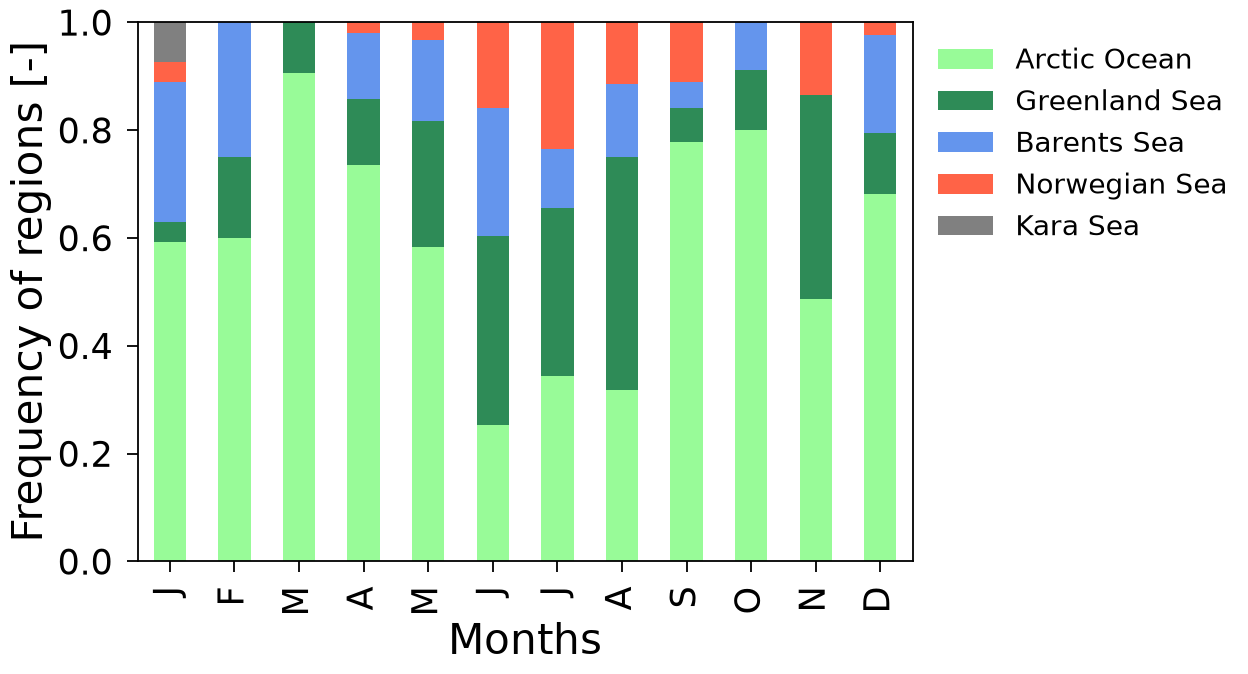

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Notebooks\Plots\FigureS22.jpeg


In [61]:
fig = produce_annual_airmass_freq(df_months_regions)
output_figure = plots_outpath / 'FigureS22.jpeg'
save_plot(fig, output_figure)